<a href="https://colab.research.google.com/github/lojainkadah185-dot/FDS/blob/main/Notebooks/Class%20Activities/Lojaen_Alkaddah_MA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <font color = blue size = 6> **Midterm Alternative (10 marks)**

# Overview:

In this homework for the midterm alternative, you will use the famous Iris dataset to explore linear regression using Python's datascience library. You will load real data, visualize relationships between variables, fit a regression line, and interpret the results.



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Learning Objectives:

- Load and explore a public dataset using the datascience Table class
- Create scatter plots with regression lines
- Calculate and interpret slope, intercept, and correlation coefficient
- Make predictions using a regression equation
- Analyze residuals to evaluate model fit


# Dataset Description
The Iris dataset is one of the most well-known datasets in data science. It contains measurements of 150 iris flowers across 3 species: setosa, versicolor, and virginica.

You can download or open Iris dataset using https://www.kaggle.com/datasets/uciml/iris .


## Setup Instructions [0 marks]

import necessary libraries

In [ ]:
!pip install datascience
from datascience import *
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
%matplotlib inline

In [ ]:
from datascience import *
%matplotlib inline
#path_data = '../../../assets/data/'
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import numpy as np

Load data to a table (Use the following cell to load dataset.)

In [ ]:
# Load dataset
from google.colab import files
uploaded = files.upload()
iris = Table.read_table('Iris.csv')
iris.show(5)

Saving Iris.csv to Iris (8).csv


Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
1,5.1,3.5,1.4,0.2,Iris-setosa
2,4.9,3,1.4,0.2,Iris-setosa
3,4.7,3.2,1.3,0.2,Iris-setosa
4,4.6,3.1,1.5,0.2,Iris-setosa
5,5,3.6,1.4,0.2,Iris-setosa


# Tasks

- Use the given cells to provide your Python code.
- If the question asks for an explanation, use comment lines ('#') to provide your explanation after the code.

## <font color = blue size  = 5>**Task 1: Data Exploration (1 Mark)**

**Task Description:**

- Answer the following questions by providing appropriate Python codes


In [ ]:
# Q1. How many rows and columns does the dataset have? Print the column names.

column_names = iris.labels         # Get the column names of the iris table
row_num = iris.num_rows            # Get the total number of rows in the table
column_num = iris.num_columns      # Get the total number of columns in the tab

print("Number of rows:" , row_num)
print("Number of columns:" , column_num)
print("Column names:" , column_names)

Number of rows: 150
Number of columns: 6
Column names: ('Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species')


In [ ]:
# Q2. How many flowers are there per species? Use the .group() method.

iris.group('Species')    # Group the data by species and count how many flowers are in each species


Species,count
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


In [ ]:
# Q3. Calculate the mean, minimum, and maximum of petal_length and petal_width using numpy. Show your results.

#Petal length
petal_length = iris.column('PetalLengthCm')     # Get the petal length values from the table
min_petal_length = np.min(petal_length)         # Find the mean, minimum, and maximum of petal length
max_petal_length = np.max(petal_length)
mean_petal_length = np.mean(petal_length)

print("Petal length: ")
print("Minimum petal length: " , min_petal_length)
print("Maximum petal length: " , max_petal_length)
print("Mean petal length: " , mean_petal_length)

#Petal Width
petal_width = iris.column('PetalWidthCm')      # Get the petal width values from the table
min_petal_width = np.min(petal_width)          # Find the mean, minimum, and maximum of petal width
max_petal_width = np.max(petal_width)
mean_petal_width = np.mean(petal_width)

print("\nPetal width: ")
print("Minimum petal width: " , min_petal_width)
print("Maximum petal width: " , max_petal_width)
print("Mean petal width: " , mean_petal_width)


Petal length: 
Minimum petal length:  1.0
Maximum petal length:  6.9
Mean petal length:  3.75866666667

Petal width: 
Minimum petal width:  0.1
Maximum petal width:  2.5
Mean petal width:  1.19866666667


## <font color = blue size  = 5> **Task 2: Visualization (2 Marks)**


**Task Description:**
- Answer the following questions by providing appropriate Python codes

Text(0.5, 1.0, 'Petal lenght vs Petal width')

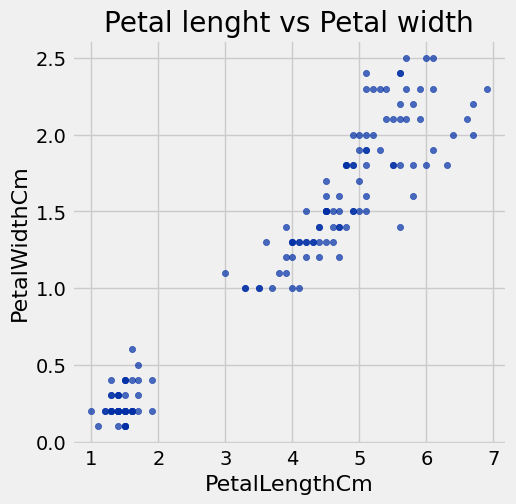

In [ ]:
# Q4. Create a scatter plot with petal_length on the x-axis and petal_width on the y-axis. Add a title to your plot.

iris.scatter( 'PetalLengthCm','PetalWidthCm' )
plt.title('Petal lenght vs Petal width')

Text(0.5, 1.0, 'Petal length vs Petal width')

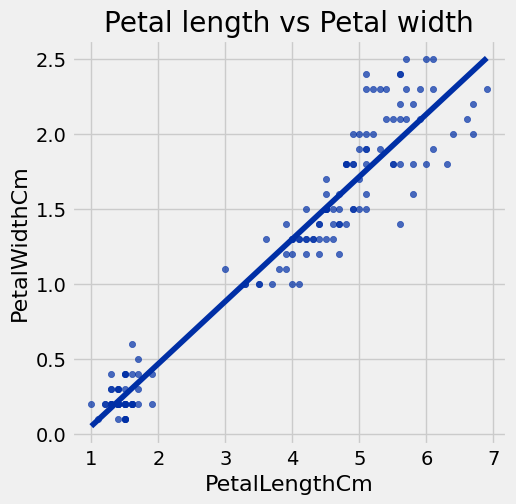

In [ ]:
# Q5. Add a regression line to the scatter plot using fit_line=True. In 1-2 sentences, describe the pattern you observe between the two variables.

iris.scatter( 'PetalLengthCm','PetalWidthCm' , fit_line = True )
plt.title('Petal length vs Petal width')

#The scatter show a strong postive relationship between petal length and petal width.
#As petal length increses, petal width also tends to increase.


## <font color = blue size  = 5> **Task 3: Linear Regression (3 Marks)**

**Task Description:**
- Use the following helper functions in your notebook to compute the regression line
- Then answer the questions

In [ ]:
def standard_units(arr):
    return (arr - np.mean(arr)) / np.std(arr)


In [ ]:
def correlation(t, x, y):
    return np.mean(standard_units(t.column(x)) * standard_units(t.column(y)))


In [ ]:
def slope(t, x, y):
    r = correlation(t, x, y)
    return r * np.std(t.column(y)) / np.std(t.column(x))


In [ ]:
def intercept(t, x, y):
    return np.mean(t.column(y)) - slope(t, x, y) * np.mean(t.column(x))


In [ ]:
# Q6. Using the helper functions above, compute and print the slope and intercept of the regression line that predicts petal_width from petal_length. Write the full regression equation.

Line_slope = slope(iris, 'PetalLengthCm', 'PetalWidthCm')           # Find the slope of the regression line
Line_intercept = intercept(iris, 'PetalLengthCm', 'PetalWidthCm')   # Find the intercept of the regression line

print("Slope = " , Line_slope)
print("Intercept = " , Line_intercept)
print("Regression equation: petal_width = " , Line_slope,"(petal_length) + " , Line_intercept)


Slope =  0.416419132285
Intercept =  -0.366514045217
Regression equation: petal_width =  0.416419132285 (petal_length) +  -0.366514045217


In [ ]:
# Q7. Use your regression equation to predict the petal width of a flower with petal_length = 4.5 cm. Show your calculation.

flower_petal_length = 4.5
flower_petal_width = Line_slope * flower_petal_length + Line_intercept
print("Calculation: ", Line_slope, "*", flower_petal_length, "+", Line_intercept)
print("The petal width of a flower with petal_length = 4.5 cm is", flower_petal_width)


Calculation:  0.416419132285 * 4.5 + -0.366514045217
The petal width of a flower with petal_length = 4.5 cm is 1.50737205007


In [ ]:
# Q8. Compute the correlation coefficient r between petal_length and petal_width. Is the relationship strong or weak? Positive or negative? Explain in 2-3 sentences.

Cor_Value = correlation(iris, 'PetalLengthCm', 'PetalWidthCm')
print("The correlation coefficient r = ", Cor_Value)

#The correlation coefficient is about 0.963, which means there is a strong positive relationship between petal length and petal width.
#Flowers with longer petals usually have wider petals.


The correlation coefficient r =  0.962757097051


## <font color = blue size  = 5> **Task 4: Residual Analysis (4 Marks)**


- Use the regression line you calculated in the following questions.

In [ ]:
# Q9. Compute the predicted petal_width for every flower using your regression equation. Add both the predicted values and the residuals (actual - predicted) as new columns to the table. Display the first 8 rows.
predictions = (iris.column('PetalLengthCm')*Line_slope + Line_intercept)
residuals = (iris.column('PetalWidthCm') - predictions)

iris = iris.with_columns('Predicted PetalWidthCm', predictions, 'Residuals', residuals)
iris.show(8)


Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,Predicted PetalWidthCm,Residuals
1,5.1,3.5,1.4,0.2,Iris-setosa,0.216473,-0.0164727
2,4.9,3,1.4,0.2,Iris-setosa,0.216473,-0.0164727
3,4.7,3.2,1.3,0.2,Iris-setosa,0.174831,0.0251692
4,4.6,3.1,1.5,0.2,Iris-setosa,0.258115,-0.0581147
5,5,3.6,1.4,0.2,Iris-setosa,0.216473,-0.0164727
6,5.4,3.9,1.7,0.4,Iris-setosa,0.341398,0.0586015
7,4.6,3.4,1.4,0.3,Iris-setosa,0.216473,0.0835273
8,5,3.4,1.5,0.2,Iris-setosa,0.258115,-0.0581147


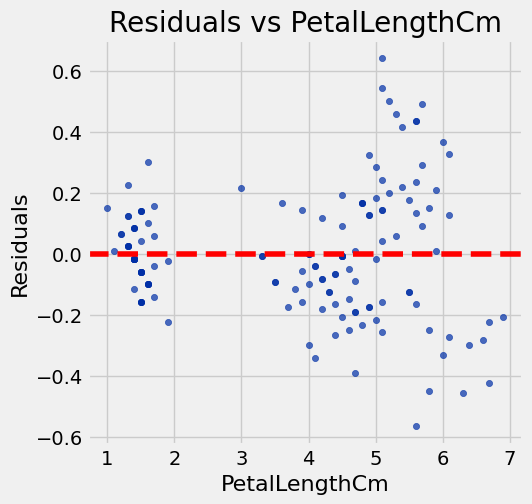

In [ ]:
# Q10. Create a scatter plot of the residuals (y-axis) vs petal_length (x-axis). Add a horizontal red dashed line at y = 0. In 2-3 sentences, interpret what this plot tells you about how well the linear model fits the data.

iris.scatter( 'PetalLengthCm','Residuals')
plt.title('Residuals vs PetalLengthCm')

plt.axhline(y=0, color="red", linestyle="--")

# The residuals are mostly around 0, which means the line fits the general trend of the data.
# But the points are not completely random, and the spread gets bigger for larger petal lengths.
# So, the linear model works fairly well, but it is not a perfect fit for all the data.

# Submission Guidelines

- Make sure all cells have been run and outputs are visible before submitting.
- Name your file: FirstName_LastName_MA.ipynb
- Add a "Open in Colab" button at the top of your notebook using the following Markdown code:
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/your-repo-path/notebook.ipynb)

- Upload your completed Jupyter Notebook to a GitHub repository.
- Submit the link to your GitHub repository in the Blackboard along with the Jupyter solution file.
- <font color = red size = 6> ATTENTION!!! </font> This is an individual assessment. Students should not work on groups and the submission should be individual.  

# Grading Rubric
based on the following criteria:

- Correctness : The solution produces the expected output using the Table abstraction .
- Clarity : Code is well-organized, readable, and includes comments explaining key steps.
- Creativity : Visualizations and analyses are presented in an engaging and insightful manner.

# Hints for Success
- Use the Table abstraction methods like .select(), .where(), .group(), .apply(), and .sample() for data manipulation.
- Refer to the slides for the regression.
- Test your code frequently to ensure it runs without errors.